<a href="https://colab.research.google.com/github/Vaishnavi200527/RollNo_39_MLDL_Lab/blob/main/MLDL_EXP6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import os


In [5]:
import kagglehub

path = kagglehub.dataset_download("rwzhang/seeds-dataset")

print("Dataset Path:", path)

print("Files:", os.listdir(path))

df = pd.read_csv(path + "/seeds_dataset.txt", delimiter='\t')

print("Dataset Shape:", df.shape)
print(df.head())

Using Colab cache for faster access to the 'seeds-dataset' dataset.
Dataset Path: /kaggle/input/seeds-dataset
Files: ['seeds_dataset.txt']
Dataset Shape: (209, 8)
   15.26  14.84   0.871  5.763  3.312  2.221   5.22  1
0  14.88  14.57  0.8811  5.554  3.333  1.018  4.956  1
1  14.29  14.09  0.9050  5.291  3.337  2.699  4.825  1
2  13.84  13.94  0.8955  5.324  3.379  2.259  4.805  1
3  16.14  14.99  0.9034  5.658  3.562  1.355  5.175  1
4  14.38  14.21  0.8951  5.386  3.312  2.462  4.956  1


In [8]:
class_col_name = df.columns[-1]
X = df.drop(columns=[class_col_name])
y = df[class_col_name]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Shape of X_scaled:", X_scaled.shape)

Shape of X: (209, 7)
Shape of y: (209,)
Shape of X_scaled: (209, 7)


In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X_scaled)

kmeans_labels = kmeans.labels_

kmeans_score = silhouette_score(X_scaled, kmeans_labels)

print("\nK-Means Silhouette Score:", kmeans_score)



K-Means Silhouette Score: 0.403775352942465


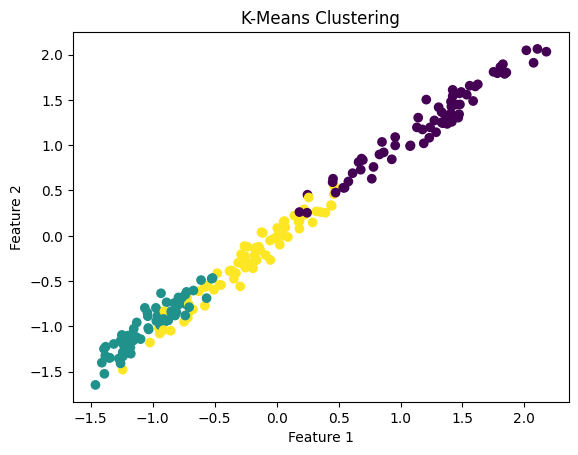

In [18]:
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.show()


In [19]:
hierarchical = AgglomerativeClustering(n_clusters=3)

hier_labels = hierarchical.fit_predict(X_scaled)

hier_score = silhouette_score(X_scaled, hier_labels)

print("Hierarchical Clustering Silhouette Score:", hier_score)


Hierarchical Clustering Silhouette Score: 0.3922387796755861


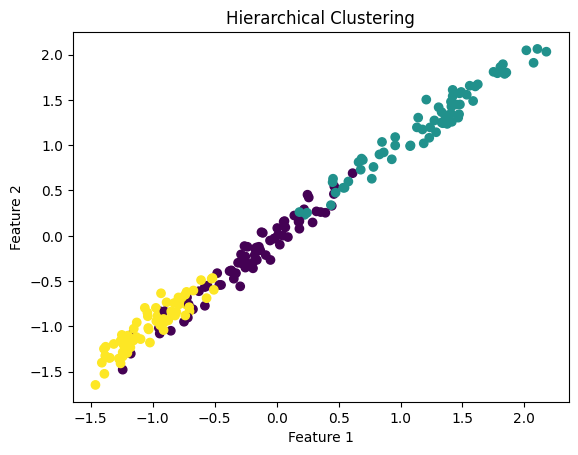

In [20]:

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hier_labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Hierarchical Clustering")
plt.show()

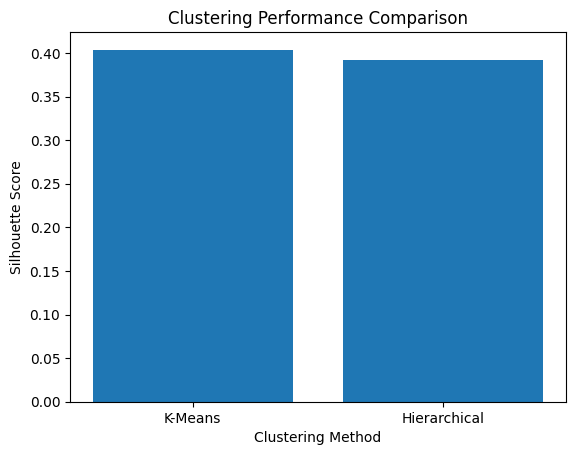

In [22]:
models = ["K-Means", "Hierarchical"]
scores = [kmeans_score, hier_score]

plt.figure()
plt.bar(models, scores)
plt.xlabel("Clustering Method")
plt.ylabel("Silhouette Score")
plt.title("Clustering Performance Comparison")
plt.show()